Task 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/trends_analysed.csv")

Task 2 — Chart 1: Top 10 Stories by Score

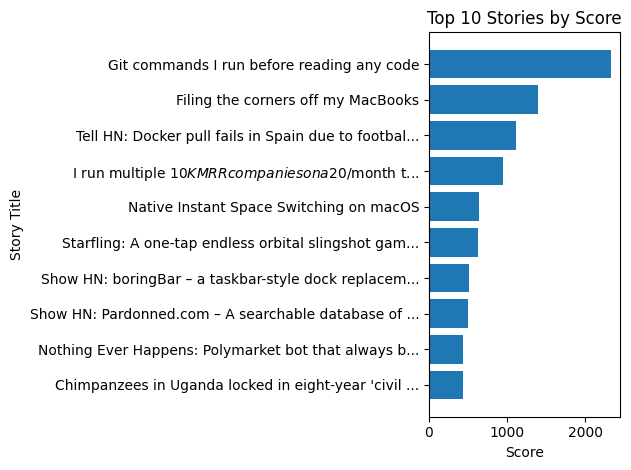

In [3]:
# Get top 10 stories
top_stories = df.nlargest(10, "score")

# Shorten long titles (max 50 chars)
top_stories["short_title"] = top_stories["title"].str[:50]

top_stories["short_title"] = top_stories["short_title"].where(
    top_stories["title"].str.len() <= 50,
    top_stories["short_title"] + "..."
)

plt.figure()

plt.barh(top_stories["short_title"], top_stories["score"])
plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")

plt.gca().invert_yaxis()  # Highest score on top

plt.tight_layout()
plt.savefig("outputs/chart1_top_stories.png")
plt.show()

Task 3 — Chart 2: Stories per Category 

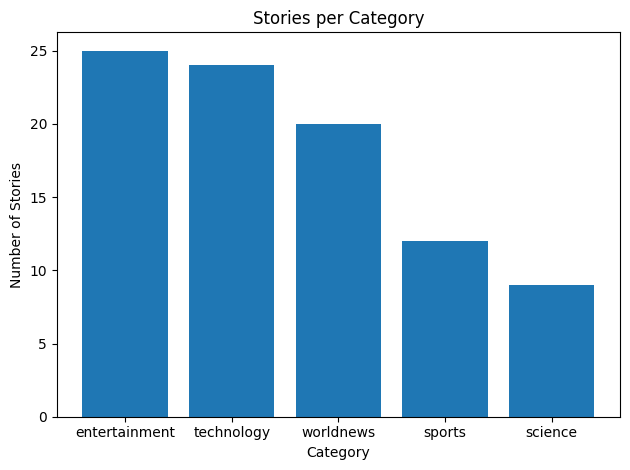

In [4]:
category_counts = df["category"].value_counts()

plt.figure()

plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")

plt.tight_layout()
plt.savefig("outputs/chart2_categories.png")
plt.show()

Task 4 — Chart 3: Score vs Comments

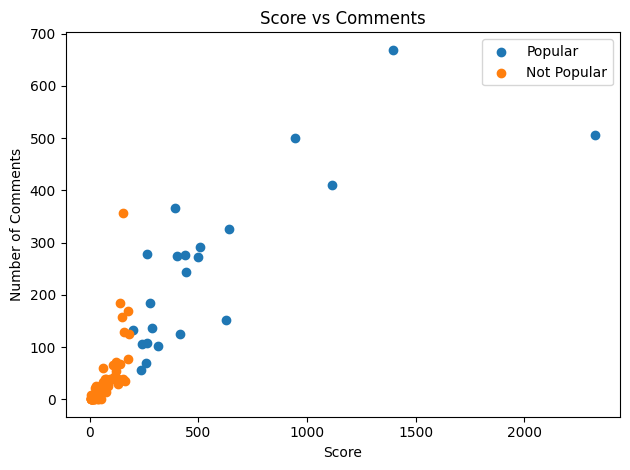

In [5]:
plt.figure()

# Split data
popular = df[df["is_popular"] == True]
not_popular = df[df["is_popular"] == False]

plt.scatter(popular["score"], popular["num_comments"], label="Popular")
plt.scatter(not_popular["score"], not_popular["num_comments"], label="Not Popular")

plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Comments")

plt.legend()

plt.tight_layout()
plt.savefig("outputs/chart3_scatter.png")
plt.show()

 Bonus — Dashboard

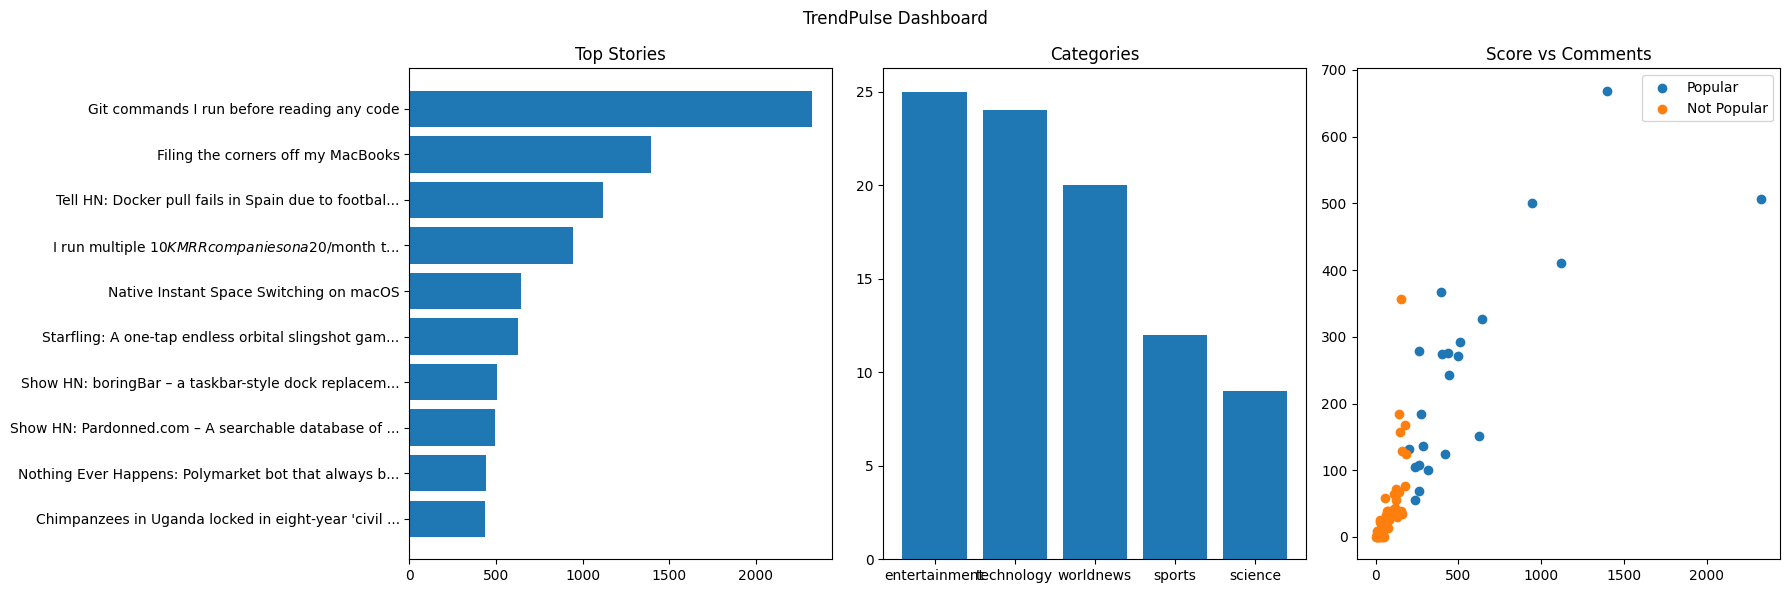

In [13]:
plt.figure(figsize=(18, 6))

# Chart 1
plt.subplot(1, 3, 1)
plt.barh(top_stories["short_title"], top_stories["score"])
plt.title("Top Stories")
plt.gca().invert_yaxis()

# Chart 2
plt.subplot(1, 3, 2)
plt.bar(category_counts.index, category_counts.values)
plt.title("Categories")

# Chart 3
plt.subplot(1, 3, 3)
plt.scatter(popular["score"], popular["num_comments"], label="Popular")
plt.scatter(not_popular["score"], not_popular["num_comments"], label="Not Popular")
plt.title("Score vs Comments")
plt.legend()

plt.suptitle("TrendPulse Dashboard")

plt.tight_layout()
plt.savefig("outputs/dashboard.png")
plt.show()